In [1]:
from datetime import datetime
import json
import sys
import os
import pandas as pd
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("/Users/zeyaddaowd/Desktop/GP/LedgerDB/aml_service/notebooks/exploration.ipynb"))) # two dirname to get to aml_service path 
    
with open(os.path.join(BASE_DIR, 'config', 'thresholds.json')) as f:
    THRESHOLDS = json.load(f)
sys.path.append(BASE_DIR)

from graph.builder import TransactionsGraph


In [2]:
transactions_path = "/Users/zeyaddaowd/Desktop/GP/LedgerDB/aml_service/IBM/amlWORLD/HI-Small_Trans.csv"
df_transactions = pd.read_csv(transactions_path)

In [3]:
cycled_money_path = "/Users/zeyaddaowd/Desktop/GP/LedgerDB/aml_service/output/accounts_cycled_money.csv"
df_cycled_money = pd.read_csv(cycled_money_path)

In [4]:
garg_index_path = "/Users/zeyaddaowd/Desktop/GP/LedgerDB/aml_service/output/accounts_garg_index.csv"
garg_df = pd.read_csv(garg_index_path)

In [5]:
df_transactions["From_Account"] = (
    df_transactions["From Bank"].astype("string")
    .str.cat(df_transactions["Account"].astype("string"), sep="_")
)
df_transactions["To_Account"] = (
    df_transactions["To Bank"].astype("string")
    .str.cat(df_transactions["Account.1"].astype("string"), sep="_")
)

In [6]:
df_transactions.drop(columns=["From Bank", "Account", "To Bank", "Account.1"], inplace=True)

In [7]:
df_transactions.head()

,Timestamp,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,From_Account,To_Account
0,2022/09/01 00:20,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0,10_8000EBD30,10_8000EBD30
1,2022/09/01 00:20,0.01,US Dollar,0.01,US Dollar,Cheque,0,3208_8000F4580,1_8000F5340
2,2022/09/01 00:00,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0,3209_8000F4670,3209_8000F4670
3,2022/09/01 00:02,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0,12_8000F5030,12_8000F5030
4,2022/09/01 00:06,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0,10_8000F5200,10_8000F5200


In [8]:
print(df_transactions["Is Laundering"].value_counts())

Is Laundering
0    5073168
1       5177
Name: count, dtype: int64


In [9]:
all_accounts = list(set(df_transactions["From_Account"]).union(set(df_transactions["To_Account"])))
laundering_transactions = df_transactions[df_transactions["Is Laundering"] == 1]
laundering_accounts = set(laundering_transactions["From_Account"]).union(set(laundering_transactions["To_Account"]))

In [10]:
account_df = pd.DataFrame({
    "Account_ID": all_accounts,
    "is_laundering": [1 if acc in laundering_accounts else 0 for acc in all_accounts]
})

In [11]:
print("Total unique accounts:", len(all_accounts))
print("Total laundering accounts:", len(laundering_accounts))

Total unique accounts: 515088
Total laundering accounts: 6357


In [12]:
graph = TransactionsGraph()
currency_exchange = {
    "US Dollar": 52,
    "Bitcoin": 3314084,
    "Euro": 60,
    "Australian Dollar": 36.5,
    "Yuan": 7.67,
    "Rupee": 0.55,
    "Yen": 0.32,
    "Mexican Peso": 3,
    "UK Pound": 69.75,
    "Ruble": 0.72,
    "Canadian Dollar": 37.19,
    "Swiss Franc": 65.27,
    "Brazil Real": 10.24,
    "Saudi Riyal": 13.84,
    "Shekel": 17.8
}

In [13]:
df_transactions["Amount_Paid_EGP"] = df_transactions.apply(
    lambda row: row["Amount Paid"] * currency_exchange[row["Payment Currency"]],
    axis=1
)
df_transactions["Timestamp"] = pd.to_datetime(df_transactions["Timestamp"])


In [14]:
for index, row in df_transactions.iterrows():
    if index % 10000 == 0:
        print(f"Processing transaction {index} / {len(df_transactions)}")
    graph.add_transaction(from_account=row["From_Account"], to_account=row["To_Account"], amount=row["Amount_Paid_EGP"], timestamp=row["Timestamp"])

Processing transaction 0 / 5078345
Processing transaction 10000 / 5078345
Processing transaction 20000 / 5078345
Processing transaction 30000 / 5078345
Processing transaction 40000 / 5078345
Processing transaction 50000 / 5078345
Processing transaction 60000 / 5078345
Processing transaction 70000 / 5078345
Processing transaction 80000 / 5078345
Processing transaction 90000 / 5078345
Processing transaction 100000 / 5078345
Processing transaction 110000 / 5078345
Processing transaction 120000 / 5078345
Processing transaction 130000 / 5078345
Processing transaction 140000 / 5078345
Processing transaction 150000 / 5078345
Processing transaction 160000 / 5078345
Processing transaction 170000 / 5078345
Processing transaction 180000 / 5078345
Processing transaction 190000 / 5078345
Processing transaction 200000 / 5078345
Processing transaction 210000 / 5078345
Processing transaction 220000 / 5078345
Processing transaction 230000 / 5078345
Processing transaction 240000 / 5078345
Processing tra

In [15]:
df_cycled_money.head()

,Account_ID,Cycled_Money,Input_Money,Output_Money
0,23402_813382840,0.0,68992.56,48972.56
1,45279_8113B3720,0.0,163172.60,0.00
2,317963_806849C10,0.0,0.00,11136.32
3,328151_80A5651F0,0.0,0.00,6458.31
4,310352_806073290,0.0,0.00,4972.80


In [16]:
print(len(df_cycled_money))
print(len(account_df))

515088
515088


In [17]:
df_data = pd.merge(account_df, df_cycled_money, how="left", left_on="Account_ID", right_on="Account_ID")

In [18]:
df_data.head()

,Account_ID,is_laundering,Cycled_Money,Input_Money,Output_Money
0,44873_8109E8290,0,0.0,5.033911e+04,182401.406
1,14290_803A593D0,0,0.0,1.235560e+09,87684.000
2,29145_80B285A70,0,0.0,6.085539e+09,0.000
3,351345_812D19420,0,0.0,0.000000e+00,0.000
4,39839_8044316B0,0,0.0,0.000000e+00,0.000


In [19]:
df_data["Input_Output_Ratio"] = df_data["Input_Money"] / (df_data["Output_Money"] + 1e-6)
df_data["Cycled_Input_Ratio"] = df_data["Cycled_Money"] / (df_data["Input_Money"] + 1e-6)
df_data["Cycled_Output_Ratio"] = df_data["Cycled_Money"] / (df_data["Output_Money"] + 1e-6)
df_data["indegree"] = df_data["Account_ID"].apply(lambda x: graph.get_indegree(x))
df_data["outdegree"] = df_data["Account_ID"].apply(lambda x: graph.get_outdegree(x))

In [20]:
garg_df.head()

,Account_ID,garg_index
0,145752_810EBADA0,0.249781
1,23833_801DAE230,0.333333
2,18180_80C129240,1.000000
3,3305_800582890,1.000000
4,14_8021606B0,1.000000


In [21]:
df_data = pd.merge(df_data, garg_df[["Account_ID", "garg_index"]], how="left", left_on="Account_ID", right_on="Account_ID")

In [22]:
df_data.head()

,Account_ID,is_laundering,Cycled_Money,Input_Money,Output_Money,Input_Output_Ratio,Cycled_Input_Ratio,Cycled_Output_Ratio,indegree,outdegree,garg_index
0,44873_8109E8290,0,0.0,5.033911e+04,182401.406,2.759798e-01,0.0,0.0,1,1,0.500000
1,14290_803A593D0,0,0.0,1.235560e+09,87684.000,1.409105e+04,0.0,0.0,2,1,0.500000
2,29145_80B285A70,0,0.0,6.085539e+09,0.000,6.085539e+15,0.0,0.0,3,0,0.333333
3,351345_812D19420,0,0.0,0.000000e+00,0.000,0.000000e+00,0.0,0.0,0,0,0.000000
4,39839_8044316B0,0,0.0,0.000000e+00,0.000,0.000000e+00,0.0,0.0,0,0,0.000000


In [23]:
df_data["Transactions_Out"] = df_data["Account_ID"].apply(lambda x: graph.graph.out_degree(x) if x in graph.graph else 0) ## out_degree of graph is number of edges
df_data["Transactions_In"] = df_data["Account_ID"].apply(lambda x: graph.graph.in_degree(x) if x in graph.graph else 0) ## in_degree of graph is number of edges

In [24]:
print(df_data["Transactions_In"])

0          2
1         27
2         11
3          0
4          0
          ..
515083     0
515084     0
515085     4
515086     0
515087    46
Name: Transactions_In, Length: 515088, dtype: int64


In [25]:
df_data["Avg_TX_in"] = df_data["Input_Money"] / (df_data["Transactions_In"] + 1e-6)
df_data["Avg_TX_out"] = df_data["Output_Money"] / (df_data["Transactions_Out"] + 1e-6)
df_data["Transactions_Per_Input"] = df_data["Transactions_In"] / (df_data["indegree"] + 1e-6)
df_data["Transactions_Per_Output"] = df_data["Transactions_Out"] / (df_data["outdegree"] + 1e-6)

In [26]:
print(df_data.columns)

Index(['Account_ID', 'is_laundering', 'Cycled_Money', 'Input_Money',
       'Output_Money', 'Input_Output_Ratio', 'Cycled_Input_Ratio',
       'Cycled_Output_Ratio', 'indegree', 'outdegree', 'garg_index',
       'Transactions_Out', 'Transactions_In', 'Avg_TX_in', 'Avg_TX_out',
       'Transactions_Per_Input', 'Transactions_Per_Output'],
      dtype='object')


In [27]:
df_data.to_csv("/Users/zeyaddaowd/Desktop/GP/LedgerDB/aml_service/output/final_features.csv", index=False)

In [28]:
print(min(df_data["garg_index"]), max(df_data["garg_index"]))

-0.9999999999900002 0.9999999999988888


In [29]:
import numpy as np

In [30]:
# df_data["cycled_money_log"] = np.log1p(df_data["Cycled_Money"])
# df_data["has_cycles"] = (df_data["Cycled_Money"] > 0).astype(int)
# df_data["cycled_ratio_log"] = np.log1p(df_data["Cycled_Output_Ratio"])

## EDA

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. class distribution
df_data["is_laundering"].value_counts()
# expect ~0.1% positive

# 2. feature distributions by class
target = "is_laundering"
features = df_data.columns.difference(["Account_ID", target])
# for feature in features:
#     fig, ax = plt.subplots()
#     df_data.groupby(target)[feature].hist(
#         alpha=0.5, ax=ax, bins=50)
#     ax.set_title(feature)
#     plt.savefig(f"eda_{feature}.png")

# 3. correlation matrix
# corr = df_data[features].corr()
# sns.heatmap(corr, annot=True)
# plt.savefig("correlation_matrix.png")

# 4. cycled money distribution specifically
print(df_data.groupby(target)["Cycled_Money"].describe())
# if cycled_money is 0 for most laundering accounts
# it means cycles aren't the main pattern in IBM dataset

                  count          mean           std  min  25%  50%  75%  \
is_laundering                                                             
0              508731.0    970.753158  4.053271e+04  0.0  0.0  0.0  0.0   
1                6357.0  68943.138088  3.768429e+06  0.0  0.0  0.0  0.0   

                        max  
is_laundering                
0              1.271064e+07  
1              2.995504e+08  


In [32]:
df_data.head()

,Account_ID,is_laundering,Cycled_Money,Input_Money,Output_Money,Input_Output_Ratio,Cycled_Input_Ratio,Cycled_Output_Ratio,indegree,outdegree,garg_index,Transactions_Out,Transactions_In,Avg_TX_in,Avg_TX_out,Transactions_Per_Input,Transactions_Per_Output
0,44873_8109E8290,0,0.0,5.033911e+04,182401.406,2.759798e-01,0.0,0.0,1,1,0.500000,1,2,2.516954e+04,182401.223599,1.999998,0.999999
1,14290_803A593D0,0,0.0,1.235560e+09,87684.000,1.409105e+04,0.0,0.0,2,1,0.500000,30,27,4.576147e+07,2922.799903,13.499993,29.999970
2,29145_80B285A70,0,0.0,6.085539e+09,0.000,6.085539e+15,0.0,0.0,3,0,0.333333,0,11,5.532308e+08,0.000000,3.666665,0.000000
3,351345_812D19420,0,0.0,0.000000e+00,0.000,0.000000e+00,0.0,0.0,0,0,0.000000,0,0,0.000000e+00,0.000000,0.000000,0.000000
4,39839_8044316B0,0,0.0,0.000000e+00,0.000,0.000000e+00,0.0,0.0,0,0,0.000000,0,0,0.000000e+00,0.000000,0.000000,0.000000


In [33]:
print(features)

Index(['Avg_TX_in', 'Avg_TX_out', 'Cycled_Input_Ratio', 'Cycled_Money',
       'Cycled_Output_Ratio', 'Input_Money', 'Input_Output_Ratio',
       'Output_Money', 'Transactions_In', 'Transactions_Out',
       'Transactions_Per_Input', 'Transactions_Per_Output', 'garg_index',
       'indegree', 'outdegree'],
      dtype='object')


## Train

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [35]:
X, y = df_data[features], df_data[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintains the ratio in both splits
)

In [36]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [10, 50, 100], 
    'max_samples': [0.5, 0.8]
}
## Scoring Changed from F1 score to average precision which calculates area under precision-recall curve
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='average_precision',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'max_samples': [0.5, 0.8],
                         'min_samples_leaf': [10, 50, 100],
                         'n_estimators': [100, 200]},
             scoring='average_precision')

In [37]:
best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)


Best Hyperparameters: {'max_depth': 15, 'max_samples': 0.8, 'min_samples_leaf': 50, 'n_estimators': 200}


In [38]:
# Evaluation on test set
from sklearn.metrics import classification_report, confusion_matrix
threshold = 0.3
print("Performance On Train Set:")
y_pred_train_proba = best_model.predict_proba(X_train)[:, 1]
y_pred_train = (y_pred_train_proba > threshold).astype(int)
print(classification_report(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))

print("Performance on Test Set:")
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > threshold).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))



Performance On Train Set:
              precision    recall  f1-score   support

           0       1.00      0.70      0.82    406984
           1       0.04      0.99      0.08      5086

    accuracy                           0.70    412070
   macro avg       0.52      0.85      0.45    412070
weighted avg       0.99      0.70      0.81    412070

[[283928 123056]
 [    31   5055]]
Performance on Test Set:
              precision    recall  f1-score   support

           0       1.00      0.69      0.82    101747
           1       0.03      0.87      0.07      1271

    accuracy                           0.70    103018
   macro avg       0.52      0.78      0.44    103018
weighted avg       0.99      0.70      0.81    103018

[[70526 31221]
 [  162  1109]]


AUC-PR: 0.14651057447502863
AUC-ROC: 0.8790857936862678


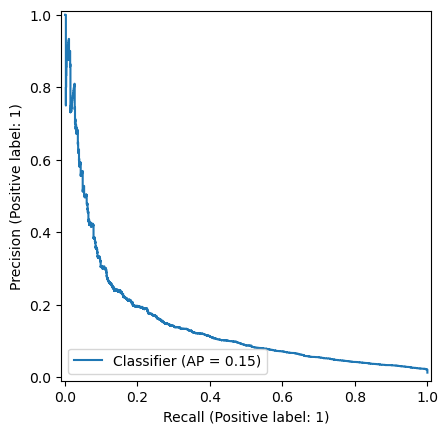

In [39]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    PrecisionRecallDisplay
)

y_proba = best_model.predict_proba(X_test)[:, 1]

print("AUC-PR:", average_precision_score(y_test, y_proba))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))

# plot precision-recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.savefig("pr_curve.png")

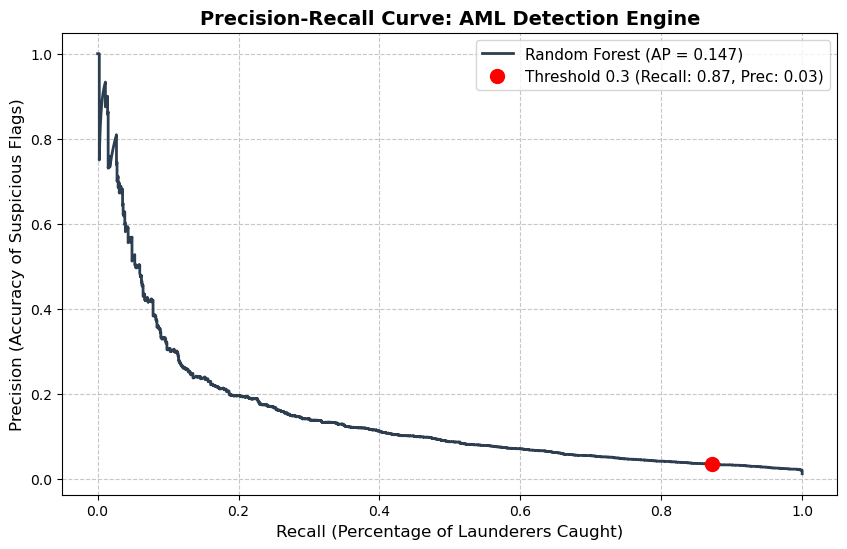

In [40]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Get the raw probabilities for the positive class (Laundering)
y_probs = best_model.predict_proba(X_test)[:, 1] ## probability it belongs to 1

# 2. Calculate Precision, Recall, and the corresponding Thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# 3. Calculate Average Precision (AP) for the legend
ap_score = average_precision_score(y_test, y_probs)

# 4. Initialize the plot
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'Random Forest (AP = {ap_score:.3f})', 
         color='#2c3e50', linewidth=2)

# 5. Highlight your current 0.3 threshold
# We find the index in the thresholds array that is closest to 0.3
closest_idx = np.argmin(np.abs(thresholds - 0.3))
plt.plot(recall[closest_idx], precision[closest_idx], 'ro', markersize=10, 
         label=f'Threshold 0.3 (Recall: {recall[closest_idx]:.2f}, Prec: {precision[closest_idx]:.2f})')

# 6. Formatting for a presentation-ready chart
plt.xlabel('Recall (Percentage of Launderers Caught)', fontsize=12)
plt.ylabel('Precision (Accuracy of Suspicious Flags)', fontsize=12)
plt.title('Precision-Recall Curve: AML Detection Engine', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Save the plot cleanly for your CBDC documentation
plt.savefig('precision_recall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [41]:
import joblib
joblib.dump(best_model, 'best_model_rf.pkl')

['best_model_rf.pkl']

In [42]:
import lightgbm as lgb

# LightGBM handles imbalance natively with scale_pos_weight
# roughly equal to (count_negative / count_positive)
ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

lgb_model = lgb.LGBMClassifier(
    scale_pos_weight=ratio,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)
param_grid = {
    'n_estimators': [100, 300],          # Number of sequential trees
    'learning_rate': [0.05, 0.1],        # How aggressive each tree corrects the last one
    'num_leaves': [31, 50],              # Maximum number of leaves per tree (default is 31)
    'max_depth': [5, 10],                # Hard limit on depth to prevent memorization
    'min_child_samples': [20, 50],       # Minimum accounts required in a leaf to form a rule
    'subsample': [0.8]                   # Use 80% of data per tree to improve generalization
}

# 4. Run the Grid Search (Using your existing StratifiedKFold 'cv')
grid_search_lgb = GridSearchCV(
    estimator=lgb_model, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='average_precision', 
    n_jobs=-1
)

print("Starting LightGBM Grid Search...")
grid_search_lgb.fit(X_train, y_train)
print("Best Parameters:", grid_search_lgb.best_params_)

[LightGBM] [Info] Number of positive: 5086, number of negative: 406984
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005965 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3129
[LightGBM] [Info] Number of data points in the train set: 412070, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.012343 -> initscore=-4.382282
[LightGBM] [Info] Start training from score -4.382282
Starting LightGBM Grid Search...
[LightGBM] [Info] Number of positive: 4069, number of negative: 325587
[LightGBM] [Info] Number of positive: 4069, number of negative: 325587
[LightGBM] [Info] Number of positive: 4069, number of negative: 325587
[LightGBM] [Info] Number of positive: 4069, number of negative: 325587
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014693 seconds.
You can set `force_r

In [43]:
threshold = 0.3
best_model_lgb = grid_search_lgb.best_estimator_
print("Performance On Train Set:")
y_pred_train_proba = best_model_lgb.predict_proba(X_train)[:, 1]
y_pred_train = (y_pred_train_proba > threshold).astype(int)
print(classification_report(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))

print("Performance on Test Set:")
y_pred_proba = best_model_lgb.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > threshold).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Performance On Train Set:
              precision    recall  f1-score   support

           0       1.00      0.68      0.81    406984
           1       0.04      1.00      0.07      5086

    accuracy                           0.68    412070
   macro avg       0.52      0.84      0.44    412070
weighted avg       0.99      0.68      0.80    412070

[[275121 131863]
 [    25   5061]]
Performance on Test Set:
              precision    recall  f1-score   support

           0       1.00      0.67      0.80    101747
           1       0.03      0.89      0.06      1271

    accuracy                           0.68    103018
   macro avg       0.52      0.78      0.43    103018
weighted avg       0.99      0.68      0.80    103018

[[68568 33179]
 [  134  1137]]


AUC-PR: 0.167398190512961
AUC-ROC: 0.8783455046629636


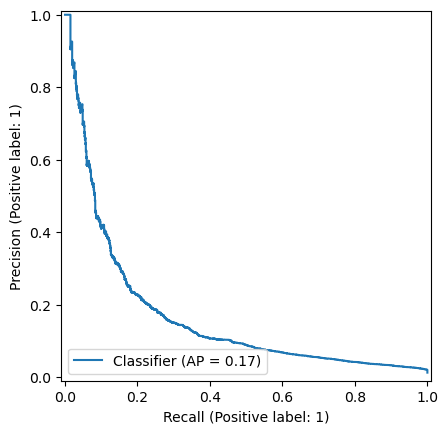

In [44]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    PrecisionRecallDisplay
)

y_proba = best_model_lgb.predict_proba(X_test)[:, 1]

print("AUC-PR:", average_precision_score(y_test, y_proba))
print("AUC-ROC:", roc_auc_score(y_test, y_proba))

# plot precision-recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.savefig("pr_curve.png")

In [45]:
joblib.dump(best_model_lgb, 'best_model_lgb.pkl')

['best_model_lgb.pkl']

/var/folders/2q/6vjsrj112rb774fzn79lb71h0000gn/T/ipykernel_20681/4236506398.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')


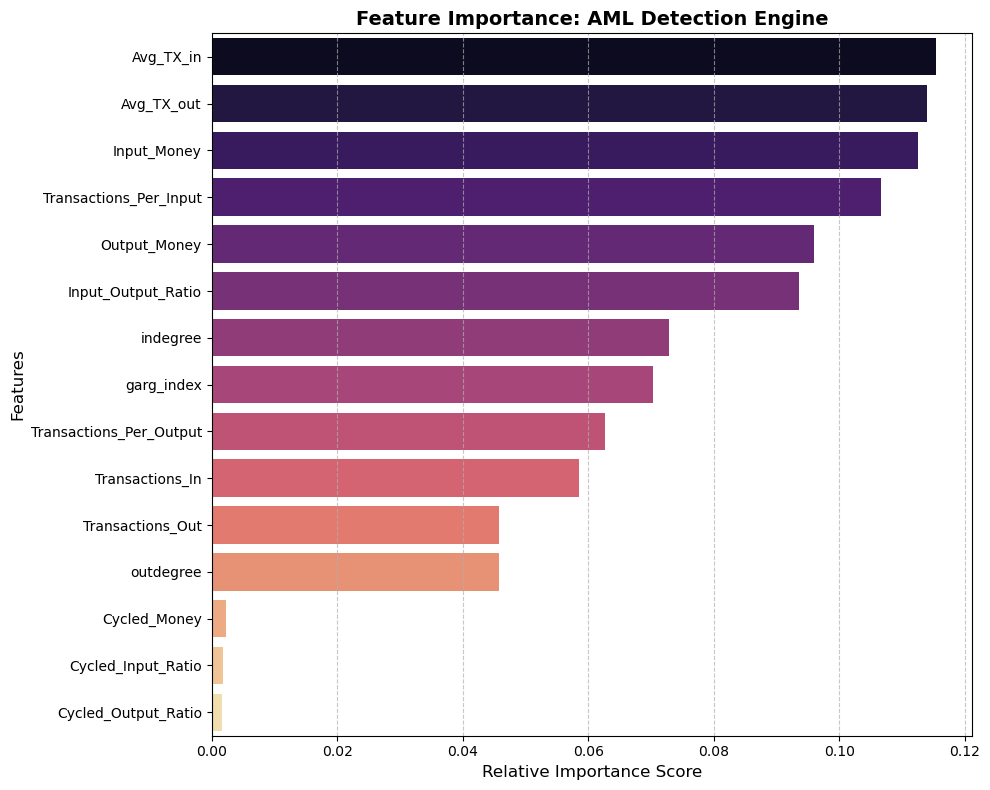

Top 5 Most Powerful AML Features:
               Feature  Importance
             Avg_TX_in    0.115386
            Avg_TX_out    0.114037
           Input_Money    0.112619
Transactions_Per_Input    0.106637
          Output_Money    0.095962


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract importances from your trained model
# This works identically for both RandomForest and LightGBM
importances = best_model.feature_importances_

# 2. Bind the importances to your feature names
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# 3. Sort them from most important to least
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma')

plt.title('Feature Importance: AML Detection Engine', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Save for your documentation
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# Print the raw top 5 for quick inspection
print("Top 5 Most Powerful AML Features:")
print(importance_df.head(5).to_string(index=False))

In [47]:
# Check how many actual launderers have a Cycled_Money value greater than 0
launderers_with_cycles = df_data[(df_data['is_laundering'] == 1) & (df_data['Cycled_Money'] > 0)]
print(f"Launderers with cycled money: {len(launderers_with_cycles)} out of {len(df_data[df_data['is_laundering'] == 1])}")

Launderers with cycled money: 387 out of 6357


In [48]:
from sklearn.metrics import precision_recall_curve
def get_threshold_F_beta_score(model, X, y, beta = 2):
    y_proba = model.predict_proba(X)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y, y_proba)
    f_beta_scores = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-6)
    best_idx = f_beta_scores.argmax()
    return thresholds[best_idx], f_beta_scores[best_idx]

In [57]:
## Like Val
print(get_threshold_F_beta_score(best_model, X_test, y_test, beta=7))
print(get_threshold_F_beta_score(best_model_lgb, X_test, y_test, beta=7))
print(get_threshold_F_beta_score(best_model, X_test, y_test, beta=5))
print(get_threshold_F_beta_score(best_model_lgb, X_test, y_test, beta=5))

(np.float64(0.3410584866821002), np.float64(0.5916663569217011))
(np.float64(0.33550214798920935), np.float64(0.5903387104421336))
(np.float64(0.4424591933799112), np.float64(0.4838539260495592))
(np.float64(0.5005919094850163), np.float64(0.4839400527997741))


In [59]:
threshold = 0.5
best_model_lgb = grid_search_lgb.best_estimator_
print("Performance On Train Set:")
y_pred_train_proba = best_model_lgb.predict_proba(X_train)[:, 1]
y_pred_train = (y_pred_train_proba > threshold).astype(int)
print(classification_report(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))

print("Performance on Test Set:")
y_pred_proba = best_model_lgb.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > threshold).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Performance On Train Set:
              precision    recall  f1-score   support

           0       1.00      0.83      0.90    406984
           1       0.06      0.94      0.12      5086

    accuracy                           0.83    412070
   macro avg       0.53      0.88      0.51    412070
weighted avg       0.99      0.83      0.89    412070

[[335937  71047]
 [   309   4777]]
Performance on Test Set:
              precision    recall  f1-score   support

           0       1.00      0.82      0.90    101747
           1       0.05      0.74      0.09      1271

    accuracy                           0.82    103018
   macro avg       0.52      0.78      0.50    103018
weighted avg       0.98      0.82      0.89    103018

[[83709 18038]
 [  327   944]]
